In [1]:
# Set working directory
import os
os.chdir("../../")

In [2]:
# Configure file paths

# Human TF promoter-level chec-seq binding signal
sumprom_chec_glob = "sumproms/*.gz"

## Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import glob
import re

## Load data

In [4]:
sumprom_chec_files = glob.glob(sumprom_chec_glob)
sumprom_all = pd.concat([pd.read_parquet(x) for x in sumprom_chec_files], axis=1)

In [5]:
cols = sumprom_all.columns

# Keep any column containing one of these SOX factors
sox_names = ["SOX5", "SOX6", "SOX7", "SOX9", "SOX13", "SOX17", "SOX30"]

mask_sox = cols.str.contains("|".join(sox_names))

sox_for_plot = sumprom_all.loc[:, mask_sox].copy()

## Calculate and plot binding strength

In [6]:
z_cutoff = 3

def z_filtered_sum(s, z_thr=z_cutoff):
    s = s.astype(float)
    z = (s - s.mean()) / s.std(ddof=0)
    return s[z > z_thr].sum()

metric = (lambda col: z_filtered_sum(sox_for_plot[col]))

pattern = re.compile(
    r"^(SOX5|SOX6|SOX7|SOX9|SOX13|SOX17|SOX30)"
    r"(?:_(DBD|IDR))?_([0-9]+)_S([0-9]+)$"
)

data = {}
for col in sox_for_plot.columns:
    m = pattern.fullmatch(col)
    if not m: 
        continue
    name, kind, rep, seq = m.groups()
    kind = "full" if kind is None else kind.lower()
    key = (name, rep)
    data.setdefault(key, {})
    data[key][kind] = float(metric(col))

In [7]:
# Build dataframe
rows = []
for (name, rep), vals in data.items():
    rows.append({
        "name": name,
        "replicate": rep,
        "full": vals.get("full", np.nan),
        "dbd":  vals.get("dbd",  np.nan),
        "idr":  vals.get("idr",  np.nan),
    })

sox_reps = pd.DataFrame(rows)

# log-transform
sox_reps["log_full"] = np.log2(sox_reps["full"])
sox_reps["log_dbd"]  = np.log2(sox_reps["dbd"])
sox_reps["log_idr"]  = np.log2(sox_reps["idr"])

In [8]:
plotting_order = ["SOX6", "SOX5", "SOX13", "SOX17", "SOX9", "SOX7", "SOX30"]

In [9]:
def plot_binding_strength(sox_reps):

    xcol, ydbd, yidr = "log_full", "log_dbd", "log_idr"
    xlab, ylab_dbd, ylab_idr = "Full TF strength", "DBD-only strength", "non-DBD-only strength"

    median_full_by_name = sox_reps.groupby("name")[xcol].mean()
    ordered_names = [n for n in plotting_order if n in median_full_by_name.index]

    norm = plt.Normalize(median_full_by_name.min()-1, median_full_by_name.max())
    cmap = plt.cm.Blues
    name_to_color = {n: cmap(norm(median_full_by_name[n])) for n in median_full_by_name.index}

    dotted_names = {"SOX9", "SOX7", "SOX30"}

    fig, (ax_dbd, ax_idr) = plt.subplots(1, 2, figsize=(10,4.5), sharex=True, sharey=True)

    for name in sox_reps["name"].unique():

        sub = sox_reps[sox_reps["name"] == name]
        x = sub[xcol].dropna()
        y = sub[ydbd].dropna()
        if len(x)==0 or len(y)==0:
            continue

        xm, ym = x.mean(), y.mean()

        xerr = [[xm - x.min()], [x.max() - xm]]
        yerr = [[ym - y.min()], [y.max() - ym]]

        marker = "D" if name in dotted_names else "o"
        msize = 7 if name in dotted_names else 9

        ax_dbd.errorbar(
            xm, ym,
            xerr=xerr, yerr=yerr,
            fmt=marker,
            color=name_to_color[name],
            ecolor=name_to_color[name],
            alpha=0.7,
            markersize=msize,
            elinewidth=1.5,
            markeredgecolor="#333333",
            markeredgewidth=0.6
        )

    ax_dbd.set_xlabel(xlab, fontsize=12)
    ax_dbd.set_ylabel(ylab_dbd, fontsize=12)
    ax_dbd.set_title("Binding strength", fontsize=14)

    legend_handles = []

    for name in ordered_names:

        sub = sox_reps[sox_reps["name"] == name]
        x = sub[xcol].dropna()
        y = sub[yidr].dropna()
        if len(x)==0 or len(y)==0:
            continue

        xm, ym = x.mean(), y.mean()

        xerr = [[xm - x.min()], [x.max() - xm]]
        yerr = [[ym - y.min()], [y.max() - ym]]

        marker = "D" if name in dotted_names else "o"
        msize = 7 if name in dotted_names else 9

        ax_idr.errorbar(
            xm, ym,
            xerr=xerr, yerr=yerr,
            fmt=marker,
            color=name_to_color[name],
            ecolor=name_to_color[name],
            alpha=0.7,
            markersize=msize,
            elinewidth=1.5,
            markeredgecolor="#333333",
            markeredgewidth=0.6
        )

        legend_handles.append(
            Line2D([0],[0],
                   marker=marker,
                   color=name_to_color[name],
                   lw=0,
                   markersize=msize,
                   label=name)
        )

    ax_idr.set_xlabel(xlab, fontsize=12)
    ax_idr.set_ylabel(ylab_idr, fontsize=12)
    ax_idr.set_title("Binding strength", fontsize=14)

    ax_idr.legend(
        handles=legend_handles,
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        labelspacing=2.3,
        borderpad=0.5,
        handletextpad=0.2,
        handlelength=2,
        fontsize=11
    )

    plt.tight_layout(rect=[0,0,0.9,1])
    plt.show()

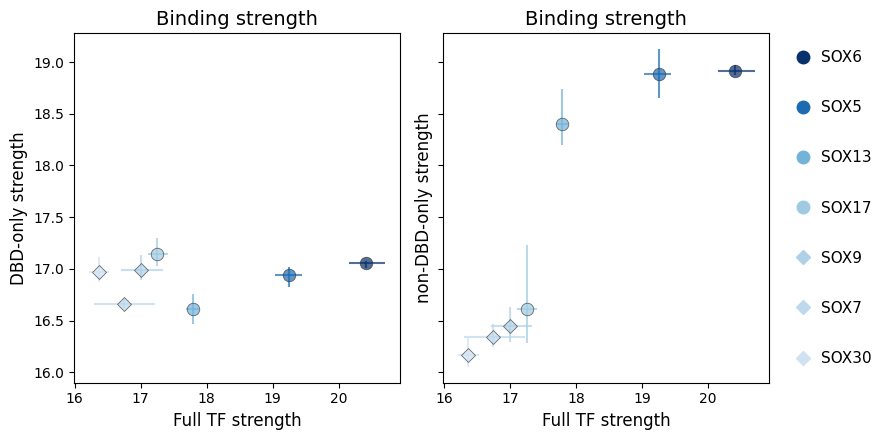

In [10]:
plot_binding_strength(sox_reps)